In [1]:
import pandas as pd 
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
#1 - Tải bộ dữ liệu 
du_lieu = load_breast_cancer()
X = du_lieu.data
y = du_lieu.target
print("Kích thước của X: ", X.shape)
print("Kích thước của y: ", y.shape)
print("Tên các đặc trưng của bộ dữ liệu:\n ", du_lieu.feature_names)
print("Tên các lớp: ", du_lieu.target_names)
tong_sl_mau = pd.Series(y).value_counts()
print("Số lương mẫu của : \n", tong_sl_mau)

Kích thước của X:  (569, 30)
Kích thước của y:  (569,)
Tên các đặc trưng của bộ dữ liệu:
  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Tên các lớp:  ['malignant' 'benign']
Số lương mẫu của : 
 1    357
0    212
Name: count, dtype: int64


In [3]:
x_train , x_test, y_train, y_test = train_test_split(X, y , random_state= 42, test_size= 0.2, stratify=y)
print("Dữ liêu của x_train: ", x_train.shape)
print("Dữ liêu của x_test: ", x_test.shape)
print("Dữ liêu của y_train: ", y_train.shape)
print("Dữ liêu của y_test: ", y_test.shape)

Dữ liêu của x_train:  (455, 30)
Dữ liêu của x_test:  (114, 30)
Dữ liêu của y_train:  (455,)
Dữ liêu của y_test:  (114,)


In [4]:
# 4 Chuẩn hóa dữ liệu 
chuan_hoa = StandardScaler()
x_train = chuan_hoa.fit_transform(x_train)
x_test = chuan_hoa.transform(x_test)
#Train dùng fit_transform
#Test dùng transform

In [5]:
# 5 hUẤN LUYỆN 2 MMMMMM
mo_hinh_lgt = LogisticRegression(max_iter= 1000)
mo_hinh_lgt.fit(x_train, y_train)
mo_hinh_svc = SVC(kernel="rbf")
mo_hinh_svc.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
# 6 dự đoán kết quả 
du_doan_lgt = mo_hinh_lgt.predict(x_test)
du_doan_svc = mo_hinh_svc.predict(x_test)

In [7]:
print("Đánh giá chỉ số logitic regression: ")
f1_logictic = f1_score(y_test, du_doan_lgt)
recall_lgt = recall_score(y_test, du_doan_lgt)
accuracy_lgt = accuracy_score(y_test, du_doan_lgt)
print("f1_score : ", f1_logictic)
print("recall_score: ", recall_lgt)
print('accuracy_score: ', accuracy_lgt)
bap_cao = classification_report(y_test, du_doan_lgt, target_names= du_lieu.target_names)
print(bap_cao)

Đánh giá chỉ số logitic regression: 
f1_score :  0.9861111111111112
recall_score:  0.9861111111111112
accuracy_score:  0.9824561403508771
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



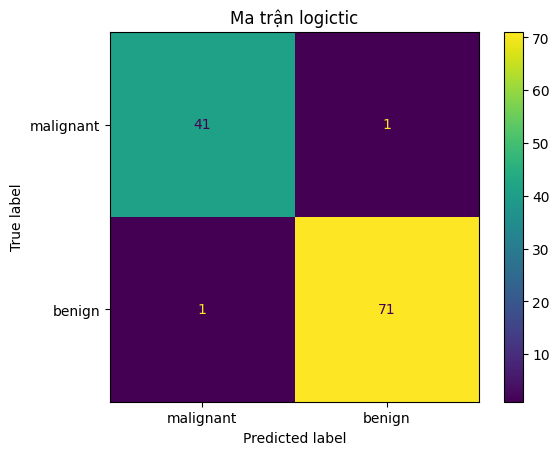

In [8]:
# 8: Vẽ biểu đồ ma trận nhầm lẫn
ma_tran = confusion_matrix(y_test, du_doan_lgt)
ma_tran = ConfusionMatrixDisplay(confusion_matrix = ma_tran,display_labels=du_lieu.target_names)
import matplotlib.pyplot as plt 
ma_tran.plot()
plt.title("Ma trận logictic")

plt.show() 

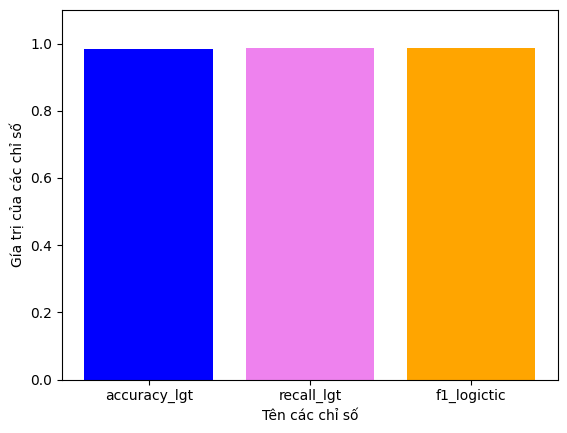

In [13]:
# Vẽ biểu đồ cột so sánh Accuracy, Recall và F1-score của hai mô hình Logistic Regression hoặc SVM.
bieu_do_cot = ["accuracy_lgt", "recall_lgt", "f1_logictic"]
gtri = [accuracy_lgt, recall_lgt, f1_logictic]
mau_sac = ["blue", "violet","orange"]
plt.bar(bieu_do_cot, gtri, color = mau_sac)
plt.ylim(0, 1.1)
plt.xlabel('Tên các chỉ số')
plt.ylabel("Gía trị của các chỉ số")
plt.show()